Exact              : 360.00 s (6.00 min)
BT                 : 357.90 s (5.97 min)


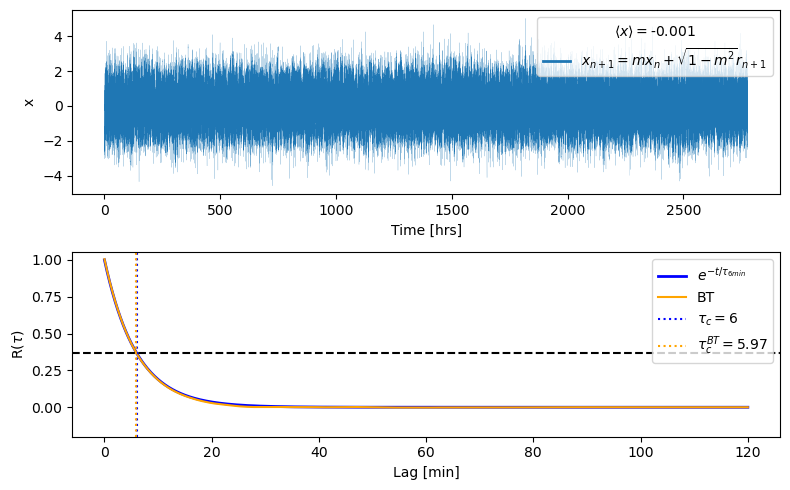

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def generate(n, dt, tau_c_true, sigma=1.0, seed=None):
    """
    Generate an AR(1) process whose theoretical ACF is

        R(tau) = exp(-tau / tau_c_true)

    Parameters
    ----------
    n : int
        Number of samples.
    dt : float
        Sample cadence.
    tau_c_true : float
        True e-folding correlation time.
    sigma : float
        Target stationary standard deviation of the process.
    seed : int or None
        Random seed.

    Returns
    -------
    x : ndarray
        Simulated time series.
    a : float
        AR(1) coefficient.
    """
    rng = np.random.default_rng(seed)

    # AR(1) coefficient that gives the target exponential correlation
    # a = np.exp(-dt / tau_c_true)
    a = (1 - dt/tau_c_true)

    # Choose innovation variance so stationary variance is sigma^2
    noise_std = sigma * np.sqrt(1.0 - a**2)

    x = np.empty(n, dtype=float)
    x[0] = rng.normal(scale=sigma)

    for i in range(1, n):
        x[i] = a * x[i - 1] + rng.normal(scale=noise_std)

    return x, a


def blackman_tukey_acf(x, max_lag=None, lag_window="blackman"):
    """
    Blackman-Tukey ACF estimator for a scalar signal.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    n = len(x)
    if n < 10:
        return np.array([])

    if max_lag is None:
        max_lag = n // 4
    max_lag = min(max_lag, n - 1)

    x = x - np.mean(x)

    acov = np.empty(max_lag + 1)
    for lag in range(max_lag + 1):
        acov[lag] = np.mean(x[: n - lag] * x[lag:])

    acov / acov[0]
    
    if lag_window is not None:
        m = max_lag + 1
        if lag_window == "blackman":
            w = np.blackman(2 * m - 1)[m - 1 :]
        elif lag_window == "hann":
            w = np.hanning(2 * m - 1)[m - 1 :]
        elif lag_window == "bartlett":
            w = np.bartlett(2 * m - 1)[m - 1 :]
        else:
            raise ValueError("lag_window must be None, 'blackman', 'hann', or 'bartlett'")
        acov = acov * w

    if acov[0] <= 0 or not np.isfinite(acov[0]):
        return np.array([])

    return acov


def efolding_time(acf, dt):
    """
    Find tau such that ACF(tau) = 1/e using linear interpolation.
    """
    acf = np.asarray(acf, dtype=float)
    if len(acf) < 2:
        return np.nan

    target = 1.0 / np.e
    idx = np.where(acf <= target)[0]

    if len(idx) == 0:
        return np.nan

    i = idx[0]
    if i == 0:
        return 0.0

    tau = np.arange(len(acf)) * dt

    x0, x1 = tau[i - 1], tau[i]
    y0, y1 = acf[i - 1], acf[i]

    if y1 == y0:
        return x1

    return x0 + (target - y0) * (x1 - x0) / (y1 - y0)



# --------------------------------------------------
# Test
# --------------------------------------------------


dt = 10.0                # seconds
tau_c_true = 360.0       # true 1/e time = 6 min
n = int(1e6)             # total samples
max_lag = 720         # 180 * 10 s = 1800 s = 30 min

x, a = generate(
    n=n,
    dt=dt,
    tau_c_true=tau_c_true,
    sigma=1,
    seed=7,
)

acf_bt = blackman_tukey_acf(x, max_lag=max_lag, lag_window='blackman')

tau = np.arange(len(acf_bt)) * dt
acf_true = np.exp(-tau / tau_c_true)

tau_e_bt = efolding_time(acf_bt, dt)

print(f"Exact              : {tau_c_true:.2f} s ({tau_c_true/60:.2f} min)")
print(f"BT                 : {tau_e_bt:.2f} s ({tau_e_bt/60:.2f} min)")

fig, ax = plt.subplots(2,1, figsize=(8, 5))

time = np.linspace(0, n * dt/3600, num = n)
ax[0].plot(time, x, label=r"$x_{n+1} = m x_{n} + \sqrt{1-m^2}r_{n+1} $", lw=0.1)
ax[0].set_ylabel('x')
ax[0].set_xlabel('Time [hrs]')
leg = ax[0].legend(title = r'$\langle x \rangle =$' + f'{np.mean(x):.3f}')
for line in leg.get_lines():
    line.set_linewidth(2.0)


ax[1].plot(tau / 60.0, acf_true, label=r"$e^{-t/\tau_{6min}}$", lw=2, c = 'blue')
ax[1].plot(tau / 60.0, acf_bt, label="BT", alpha=1, c = 'orange')

ax[1].axhline(1 / np.e, color="k", ls="--")

ax[1].axvline(tau_c_true/ 60.0, color="blue", ls=":", label = r'$\tau_c = 6$')

if np.isfinite(tau_e_bt):
    ax[1].axvline(tau_e_bt / 60.0, color="orange", ls=":", label = r'$\tau_c^{BT} = $'f'{(tau_e_bt/ 60.0):.2f}')

ax[1].set_xlabel("Lag [min]")
ax[1].set_ylabel(r"R($\tau$)")
ax[1].set_ylim(-0.2, 1.05)
ax[1].legend()
fig.tight_layout()
fig.savefig('fig/BT_test.png')
plt.show()